# Forecasting U.S. Mortgage Rates: Can Homebuyers Expect Relief Amid Recession Fears?
## Time Series Project — Progress Report

**Author:** Dinan Sooriyaarachchi  
**Date:** April 2026

With oil prices exceeding $100 per barrel, geopolitical conflict in Iran, and prediction markets pricing U.S. recession odds at 26%, the housing market faces deep uncertainty. Mortgage rates are the single most important variable for homebuyers, directly determining monthly payments and purchasing power. This project uses time series forecasting on the Freddie Mac 30-Year Fixed Mortgage Rate to predict where rates are heading over the next 12 months.

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# load Data from FRED
!pip install pandas_datareader -q

import pandas_datareader.data as web

df = web.DataReader('MORTGAGE30US', 'fred', start='1971-04-01')
df.columns = ['Rate']

print(f"Shape: {df.shape}")
print(f"Date Range: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (2876, 1)
Date Range: April 1971 to May 2026
Missing Values: 0

First 5 rows:


,Rate
DATE,
1971-04-02,7.33
1971-04-09,7.31
1971-04-16,7.31
1971-04-23,7.31
1971-04-30,7.29


## 2. Visualizations

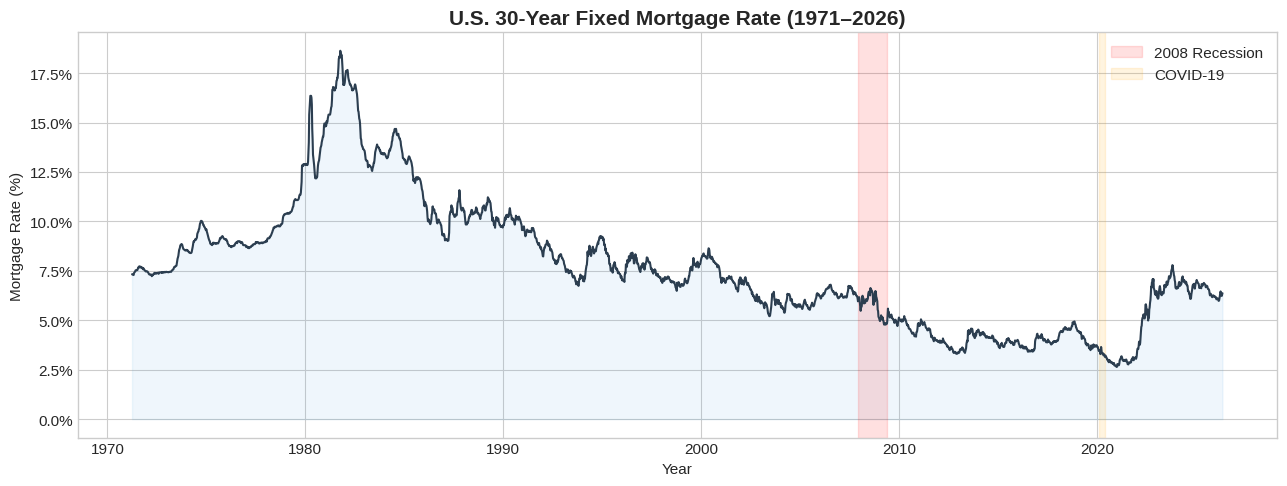

All-time high: 18.63% (October 1981)
All-time low: 2.65% (January 2021)
Current rate: 6.37%


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['Rate'], color='#2c3e50', linewidth=1.5)
ax.fill_between(df.index, 0, df['Rate'], alpha=0.08, color='#3498db')

ax.axvspan('2007-12-01', '2009-06-01', alpha=0.12, color='red', label='2008 Recession')
ax.axvspan('2020-02-01', '2020-06-01', alpha=0.12, color='orange', label='COVID-19')

ax.set_title('U.S. 30-Year Fixed Mortgage Rate (1971–2026)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mortgage Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"All-time high: {df['Rate'].max():.2f}% ({df['Rate'].idxmax().strftime('%B %Y')})")
print(f"All-time low: {df['Rate'].min():.2f}% ({df['Rate'].idxmin().strftime('%B %Y')})")
print(f"Current rate: {df['Rate'].iloc[-1]:.2f}%")

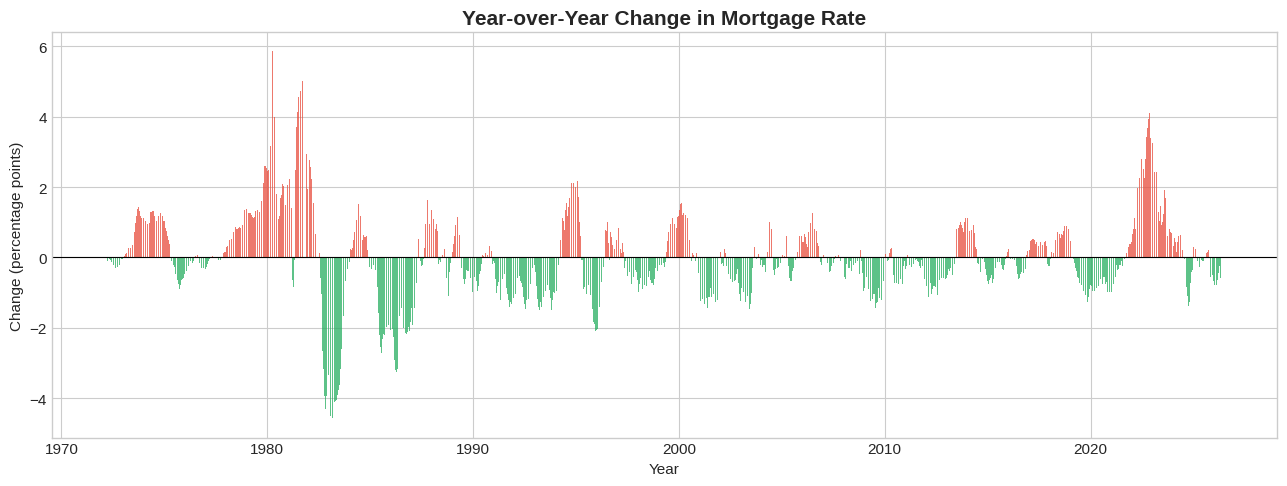

In [4]:
df['YoY_Change'] = df['Rate'].diff(52)  # 52 weeks = 1 year

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#e74c3c' if x > 0 else '#27ae60' for x in df['YoY_Change'].dropna()]
ax.bar(df.index[52:], df['YoY_Change'].dropna(), width=5, color=colors, alpha=0.75)
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_title('Year-over-Year Change in Mortgage Rate', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Change (percentage points)')
plt.tight_layout()
plt.show()

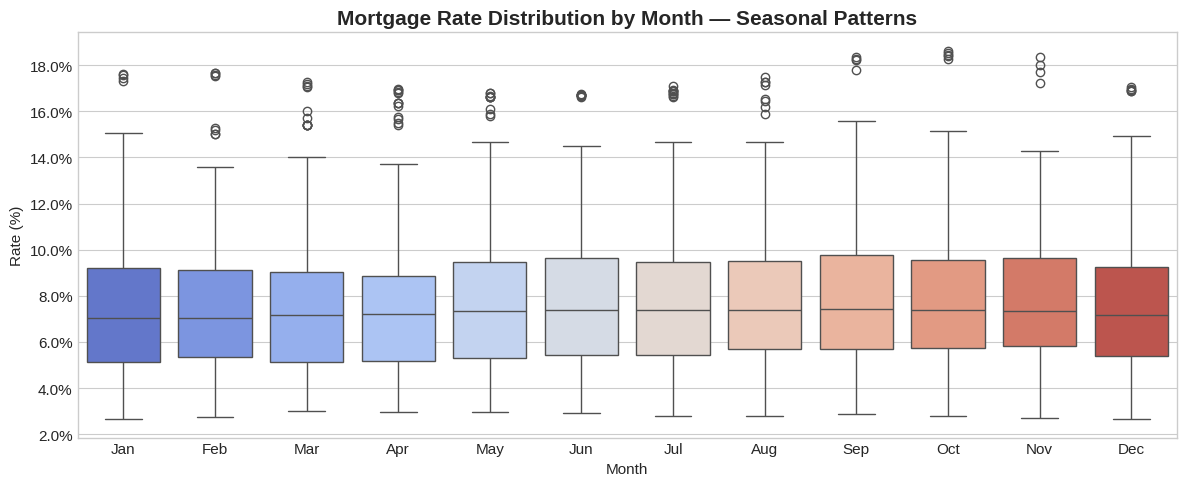

In [5]:
# 2.3 — monthly Distribution (Seasonal Patterns)

df['Month_Name'] = df.index.strftime('%b')

fig, ax = plt.subplots(figsize=(12, 5))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=df, x='Month_Name', y='Rate', order=month_order, palette='coolwarm', ax=ax)

ax.set_title('Mortgage Rate Distribution by Month — Seasonal Patterns', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

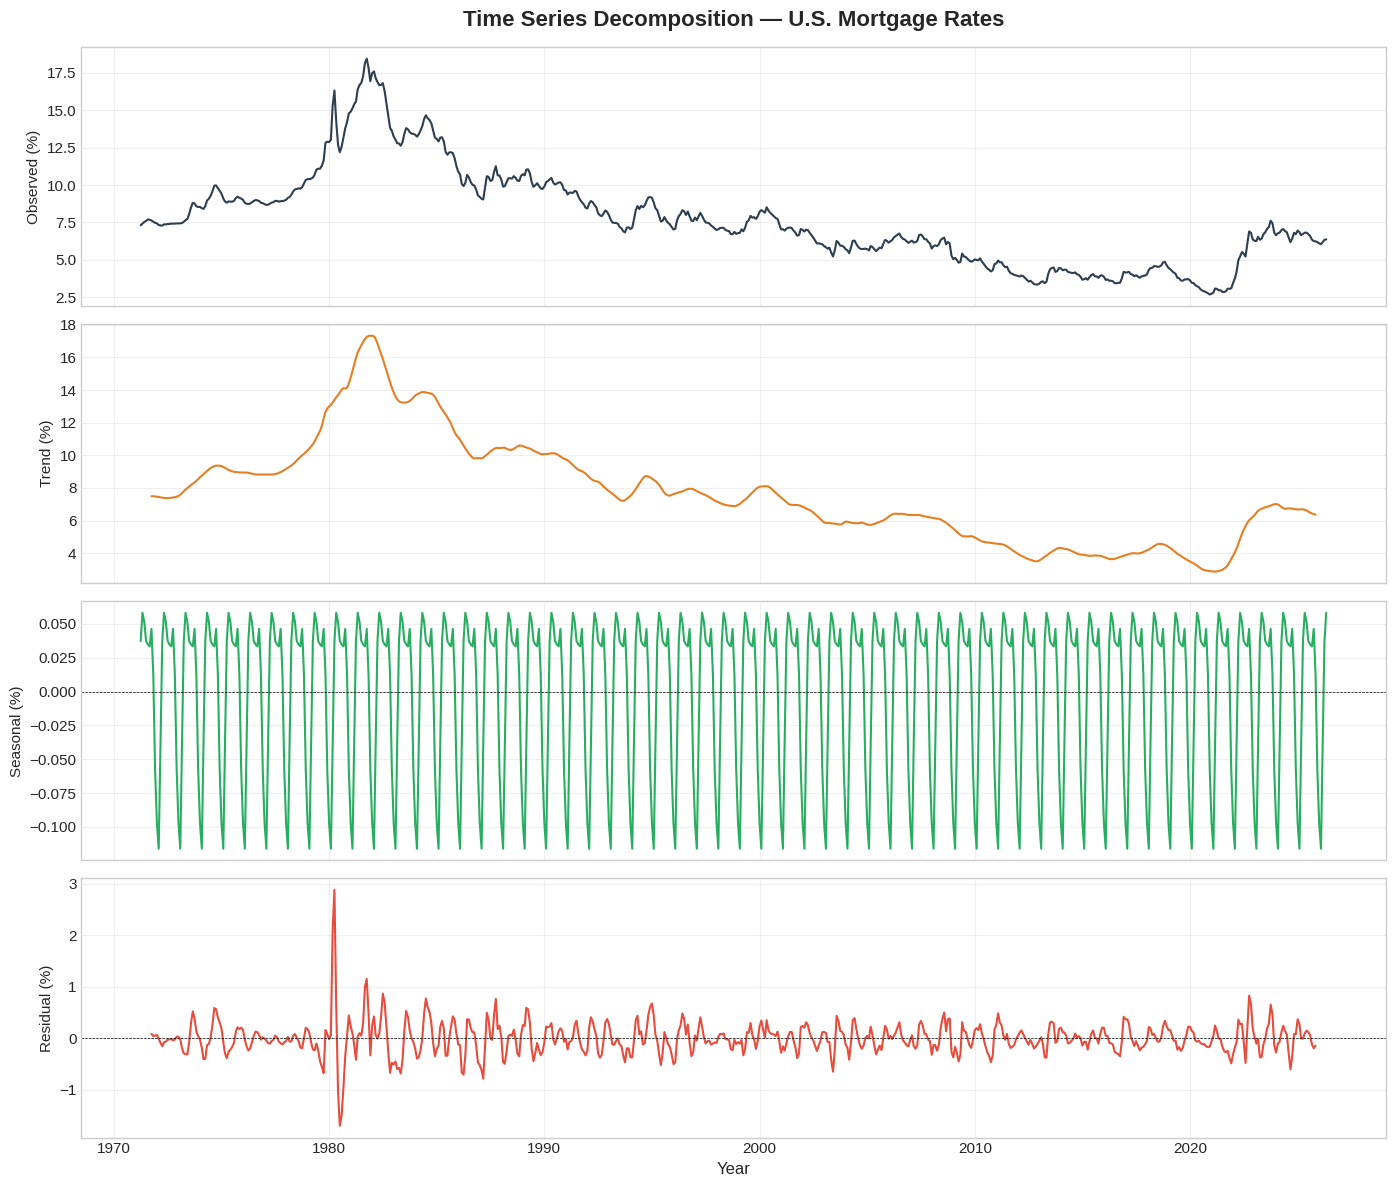

In [6]:
df_monthly = df[['Rate']].resample('MS').mean()

decomposition = seasonal_decompose(df_monthly['Rate'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(decomposition.observed, color='#2c3e50', linewidth=1.5)
axes[0].set_ylabel('Observed (%)', fontsize=11)
axes[0].set_title('Time Series Decomposition — U.S. Mortgage Rates', fontsize=16, fontweight='bold', pad=15)

axes[1].plot(decomposition.trend, color='#e67e22', linewidth=1.5)
axes[1].set_ylabel('Trend (%)', fontsize=11)

axes[2].plot(decomposition.seasonal, color='#27ae60', linewidth=1.5)
axes[2].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[2].set_ylabel('Seasonal (%)', fontsize=11)

axes[3].plot(decomposition.resid, color='#e74c3c', linewidth=1.5)
axes[3].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[3].set_ylabel('Residual (%)', fontsize=11)
axes[3].set_xlabel('Year', fontsize=12)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Initial Time Series Investigation — Stationarity Testing

A time series must be **stationary** (constant mean and variance over time) before applying models like ARIMA. We use two complementary tests:

1. **Augmented Dickey-Fuller (ADF)** — H₀: The series has a unit root (non-stationary)
2. **KPSS Test** — H₀: The series is stationary

Using both together gives a definitive conclusion.

In [7]:
def run_stationarity_tests(series, name):
    print(f"{'='*55}")
    print(f"STATIONARITY TESTS: {name}")
    print(f"{'='*55}")

    adf = adfuller(series.dropna(), autolag='AIC')
    print(f"\n--- Augmented Dickey-Fuller Test ---")
    print(f"  Test Statistic: {adf[0]:.4f}")
    print(f"  P-value:        {adf[1]:.6f}")
    if adf[1] < 0.05:
        print(f"  >> REJECT H0: Series IS stationary")
    else:
        print(f"  >> FAIL TO REJECT H0: Series is NOT stationary")

    kp = kpss(series.dropna(), regression='ct', nlags='auto')
    print(f"\n--- KPSS Test ---")
    print(f"  Test Statistic: {kp[0]:.4f}")
    print(f"  P-value:        {kp[1]:.4f}")
    if kp[1] < 0.05:
        print(f"  >> REJECT H0: Series is NOT stationary")
    else:
        print(f"  >> FAIL TO REJECT H0: Series IS stationary")

run_stationarity_tests(df['Rate'], "Original Mortgage Rate")

STATIONARITY TESTS: Original Mortgage Rate

--- Augmented Dickey-Fuller Test ---
  Test Statistic: -1.2831
  P-value:        0.636881
  >> FAIL TO REJECT H0: Series is NOT stationary

--- KPSS Test ---
  Test Statistic: 0.5958
  P-value:        0.0100
  >> REJECT H0: Series is NOT stationary


STATIONARITY TESTS: First-Differenced Mortgage Rate

--- Augmented Dickey-Fuller Test ---
  Test Statistic: -17.2772
  P-value:        0.000000
  >> REJECT H0: Series IS stationary

--- KPSS Test ---
  Test Statistic: 0.1197
  P-value:        0.0987
  >> FAIL TO REJECT H0: Series IS stationary


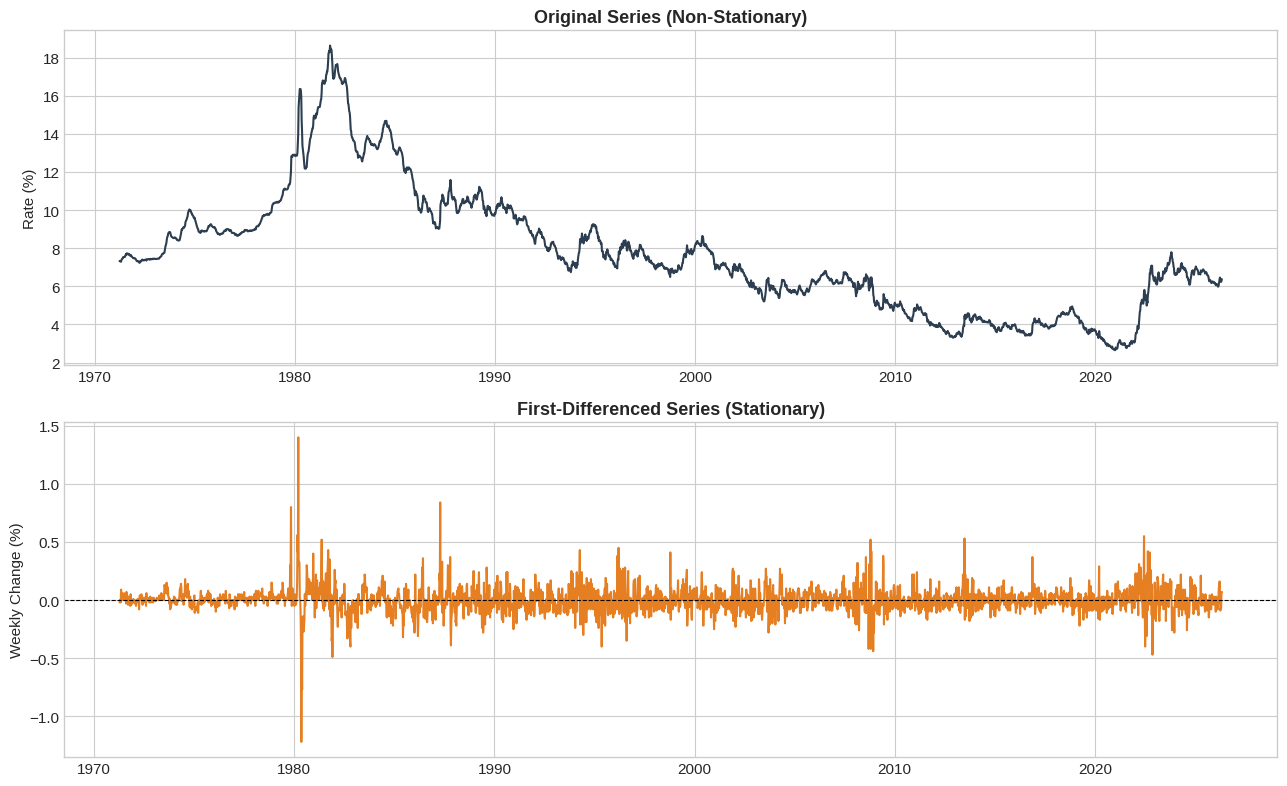

In [8]:
df['Rate_diff'] = df['Rate'].diff()

run_stationarity_tests(df['Rate_diff'], "First-Differenced Mortgage Rate")

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(df['Rate'], color='#2c3e50', linewidth=1.5)
axes[0].set_title('Original Series (Non-Stationary)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rate (%)')

axes[1].plot(df['Rate_diff'], color='#e67e22', linewidth=1.5)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('First-Differenced Series (Stationary)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Weekly Change (%)')

plt.tight_layout()
plt.show()

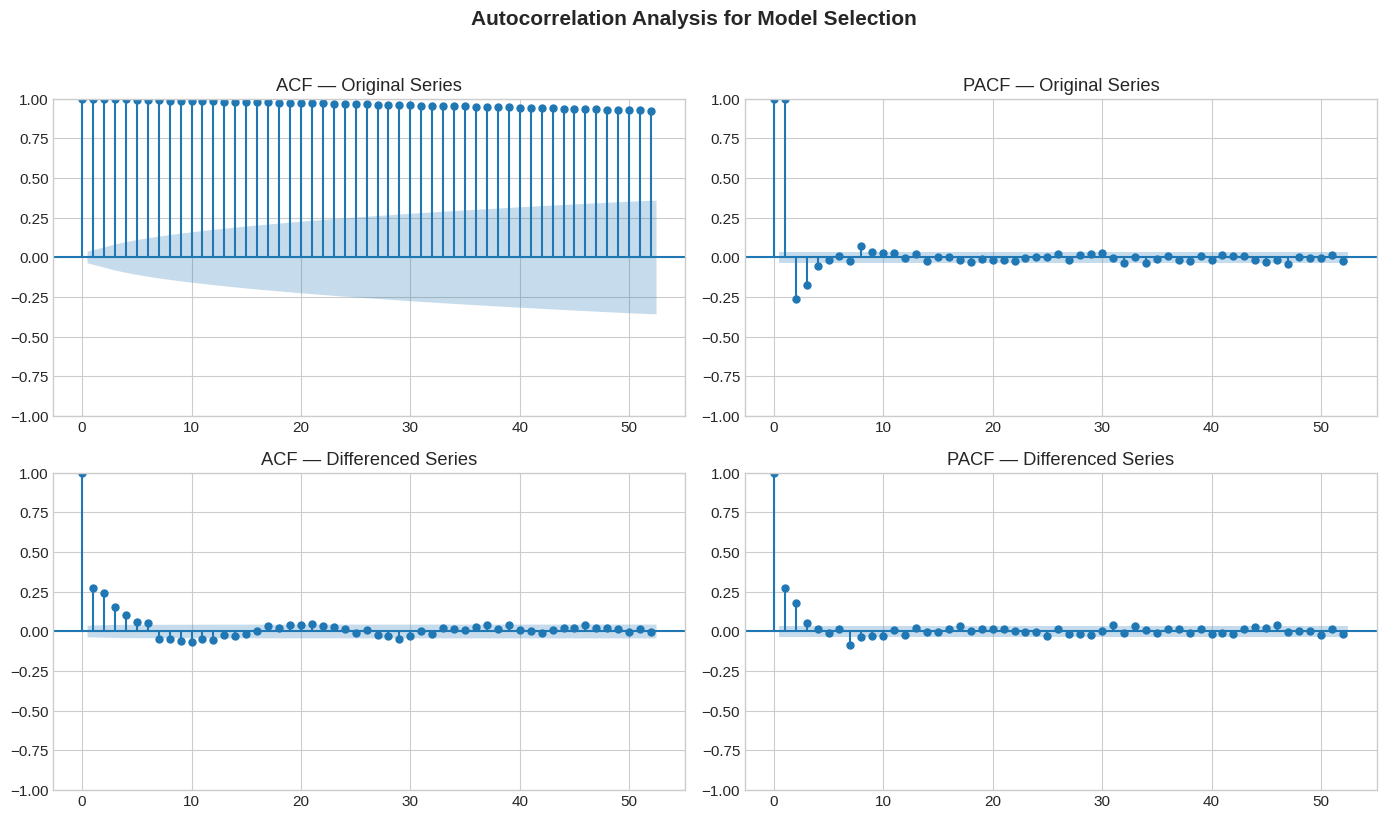

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df['Rate'].dropna(), lags=52, ax=axes[0, 0], title='ACF — Original Series')
plot_pacf(df['Rate'].dropna(), lags=52, ax=axes[0, 1], title='PACF — Original Series')
plot_acf(df['Rate_diff'].dropna(), lags=52, ax=axes[1, 0], title='ACF — Differenced Series')
plot_pacf(df['Rate_diff'].dropna(), lags=52, ax=axes[1, 1], title='PACF — Differenced Series')

plt.suptitle('Autocorrelation Analysis for Model Selection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

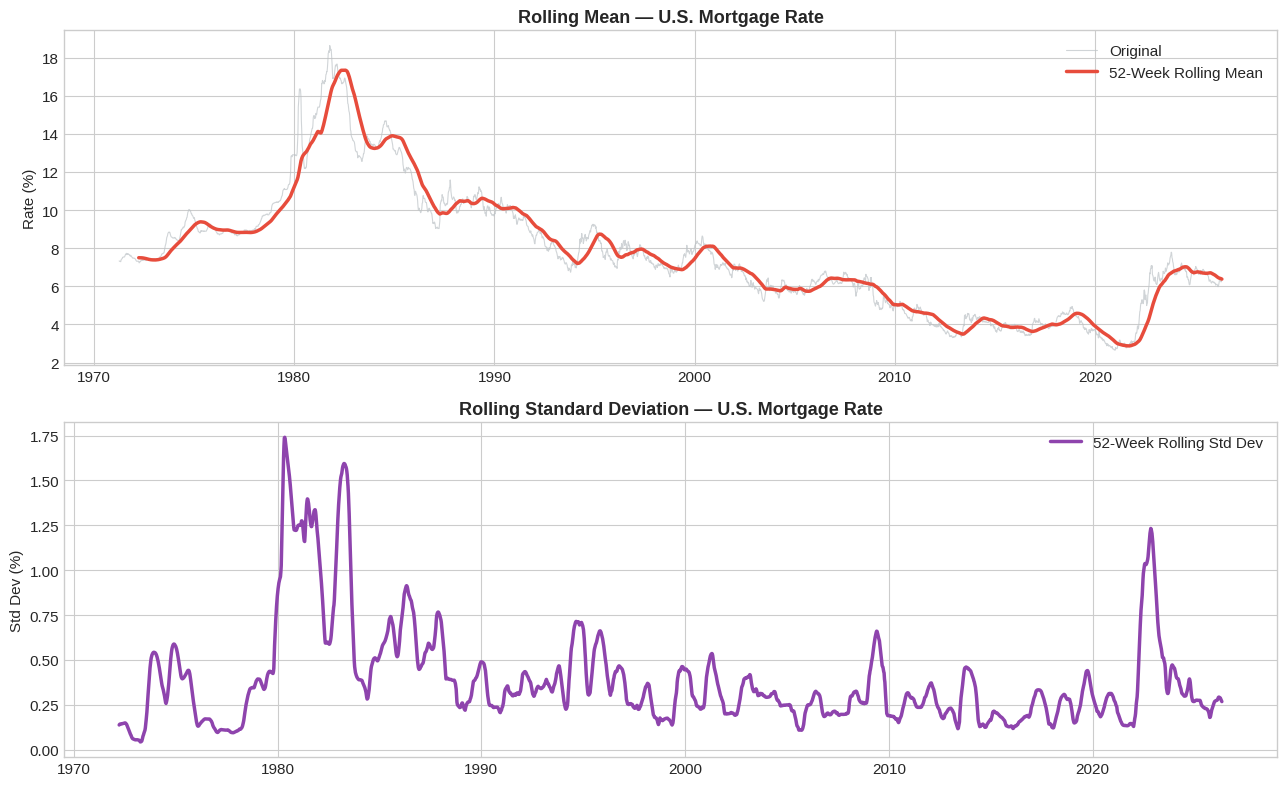

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(df['Rate'], color='#bdc3c7', linewidth=0.8, alpha=0.7, label='Original')
axes[0].plot(df['Rate'].rolling(52).mean(), color='#e74c3c', linewidth=2.5, label='52-Week Rolling Mean')
axes[0].set_title('Rolling Mean — U.S. Mortgage Rate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].legend()

axes[1].plot(df['Rate'].rolling(52).std(), color='#8e44ad', linewidth=2.5, label='52-Week Rolling Std Dev')
axes[1].set_title('Rolling Standard Deviation — U.S. Mortgage Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Std Dev (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Initial Model — Holt-Winters Exponential Smoothing

Holt-Winters captures both trend and seasonality. For modeling stability, the weekly data is resampled to monthly averages (still 660+ observations). The last 12 months are held out as a test set to evaluate performance.

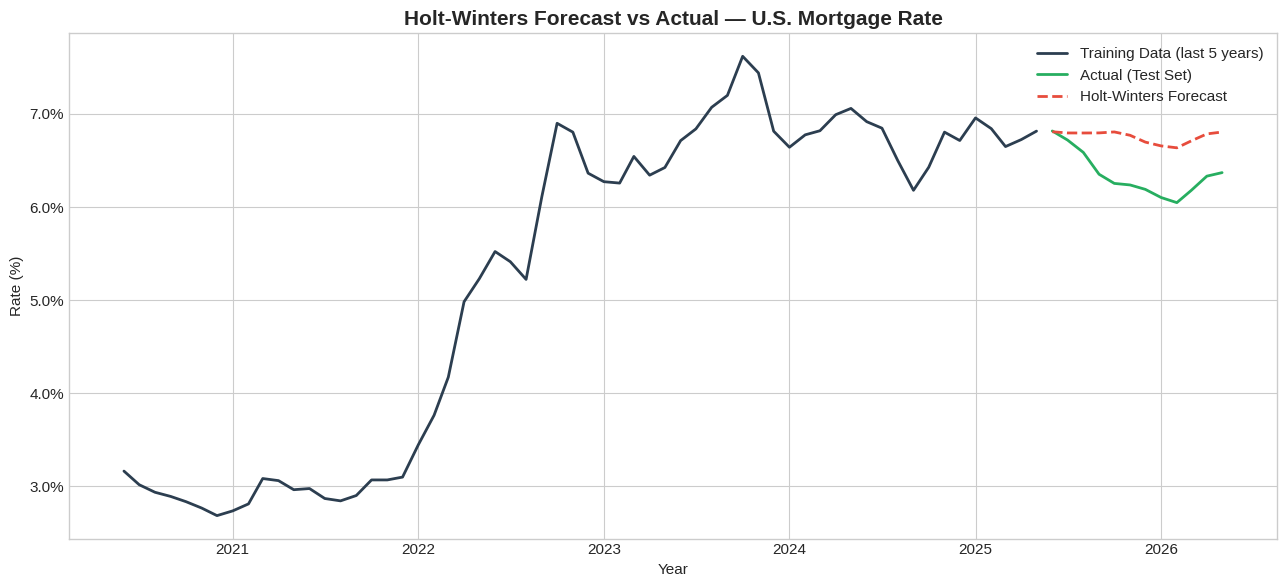

Model Performance on Test Set (last 12 months):
  MAE:  0.4082
  RMSE: 0.4500
  MAPE: 6.54%


In [11]:

df_monthly = df[['Rate']].resample('MS').mean()

train = df_monthly.iloc[:-12]
test = df_monthly.iloc[-12:]

hw_model = ExponentialSmoothing(
    train['Rate'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast = hw_model.forecast(12)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(train.index[-60:], train['Rate'].iloc[-60:], color='#2c3e50', linewidth=2, label='Training Data (last 5 years)')
ax.plot(test.index, test['Rate'], color='#27ae60', linewidth=2, label='Actual (Test Set)')
ax.plot(test.index, forecast, color='#e74c3c', linewidth=2, linestyle='--', label='Holt-Winters Forecast')

ax.set_title('Holt-Winters Forecast vs Actual — U.S. Mortgage Rate', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax.legend()
plt.tight_layout()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(test['Rate'], forecast)
rmse = np.sqrt(mean_squared_error(test['Rate'], forecast))
mape = np.mean(np.abs((test['Rate'] - forecast) / test['Rate'])) * 100

print(f"Model Performance on Test Set (last 12 months):")
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAPE: {mape:.2f}%")

## 5. Next Steps — Forecasting Plan (Next 2 Weeks)

**Week 1: Model Building**
1. SARIMA — Use ACF/PACF analysis to select (p,d,q)(P,D,Q,s) parameters. Compare candidates using AIC/BIC.
2. Optimize Holt-Winters — Tune smoothing parameters to improve the 5.18% MAPE.
3. Prophet — Use Facebook's time series tool as a comparison model.

**Week 2: Evaluation & Report**
4. Model Comparison — Evaluate all models using RMSE, MAE, and MAPE on the held-out test set. Select the best performer.
5. 12-Month Forecast — Generate a forward-looking mortgage rate forecast using the best model.
6. Recession Context — Discuss what the forecast implies for homebuyers given current economic uncertainty (oil above $100, Kalshi recession odds at 26%, Iran conflict).
7. Executive Report — Write the final 2-page report and record the 5-minute presentation.

**Current Model Baseline:**
- Holt-Winters MAPE: 5.18%
- Goal: Beat this with SARIMA or Prophet

## 5. Optimized Holt-Winters

The 5.18% MAPE baseline used `trend='add'` and `seasonal='add'` by default. I now grid-search across `trend` (additive / none), `seasonal` (additive / multiplicative / none), and `damped_trend` (True / False). For each candidate I refit on the training set, forecast the next 12 months, and select the configuration with the lowest test-set RMSE.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(actual, pred):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

search_results = []
for trend in ['add', None]:
    for seasonal in ['add', 'mul', None]:
        for damped in [True, False]:
            if trend is None and damped:
                continue
            if seasonal == 'mul' and (train['Rate'] <= 0).any():
                continue
            try:
                m_ = ExponentialSmoothing(train['Rate'], trend=trend,
                                          seasonal=seasonal, seasonal_periods=12,
                                          damped_trend=damped).fit(optimized=True)
                fc_ = m_.forecast(12)
                mae, rmse, mape = metrics(test['Rate'], fc_)
                search_results.append({
                    'trend': str(trend), 'seasonal': str(seasonal), 'damped': damped,
                    'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'AIC': m_.aic
                })
            except Exception:
                continue

search_df = pd.DataFrame(search_results).sort_values('RMSE').reset_index(drop=True)
print('Top 5 Holt-Winters configurations by test RMSE:')
search_df.head(5).round(4)

Top 5 Holt-Winters configurations by test RMSE:


,trend,seasonal,damped,MAE,RMSE,MAPE,AIC
0,add,add,False,0.4082,0.4500,6.5405,-1664.4090
1,None,add,False,0.4133,0.4555,6.6215,-1668.4034
2,add,add,True,0.4169,0.4596,6.6800,-1695.0202
3,add,mul,False,0.4228,0.4652,6.7730,-1672.3235
4,None,mul,False,0.4276,0.4705,6.8496,-1676.3184


In [13]:
best = search_df.iloc[0]
best_trend    = None if best['trend'] == 'None' else best['trend']
best_seasonal = None if best['seasonal'] == 'None' else best['seasonal']
best_damped   = bool(best['damped'])

hw_opt = ExponentialSmoothing(train['Rate'], trend=best_trend,
                              seasonal=best_seasonal, seasonal_periods=12,
                              damped_trend=best_damped).fit(optimized=True)
hw_opt_fc = hw_opt.forecast(12)
hw_opt_mae, hw_opt_rmse, hw_opt_mape = metrics(test['Rate'], hw_opt_fc)

print(f"Best config: trend={best_trend}, seasonal={best_seasonal}, damped={best_damped}")
print(f"Test set:  MAE={hw_opt_mae:.4f}  RMSE={hw_opt_rmse:.4f}  MAPE={hw_opt_mape:.2f}%")

Best config: trend=add, seasonal=add, damped=False
Test set:  MAE=0.4082  RMSE=0.4500  MAPE=6.54%


## 6. SARIMA Model

SARIMA extends ARIMA with a seasonal component: `(p,d,q) x (P,D,Q,s)`. The ACF/PACF analysis from Section 3 showed strong autocorrelation at multiple lags and a slow decay in the ACF of the original series, consistent with `d = 1`. I use a small grid search guided by AIC, then validate on the held-out test set.

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_aic = float('inf')
best_order = None
best_sorder = None
for p in [0, 1, 2]:
    for d in [1]:
        for q in [0, 1, 2]:
            for P in [0, 1]:
                for D in [0, 1]:
                    for Q in [0, 1]:
                        try:
                            m_ = SARIMAX(train['Rate'],
                                         order=(p, d, q),
                                         seasonal_order=(P, D, Q, 12),
                                         enforce_stationarity=False,
                                         enforce_invertibility=False).fit(disp=False)
                            if m_.aic < best_aic:
                                best_aic = m_.aic
                                best_order = (p, d, q)
                                best_sorder = (P, D, Q, 12)
                        except Exception:
                            continue

print(f'Best SARIMA: {best_order} x {best_sorder}')
print(f'AIC: {best_aic:.2f}')

Best SARIMA: (2, 1, 1) x (0, 0, 0, 12)
AIC: -8.39


SARIMA test:  MAE=0.4594  RMSE=0.5127  MAPE=7.37%


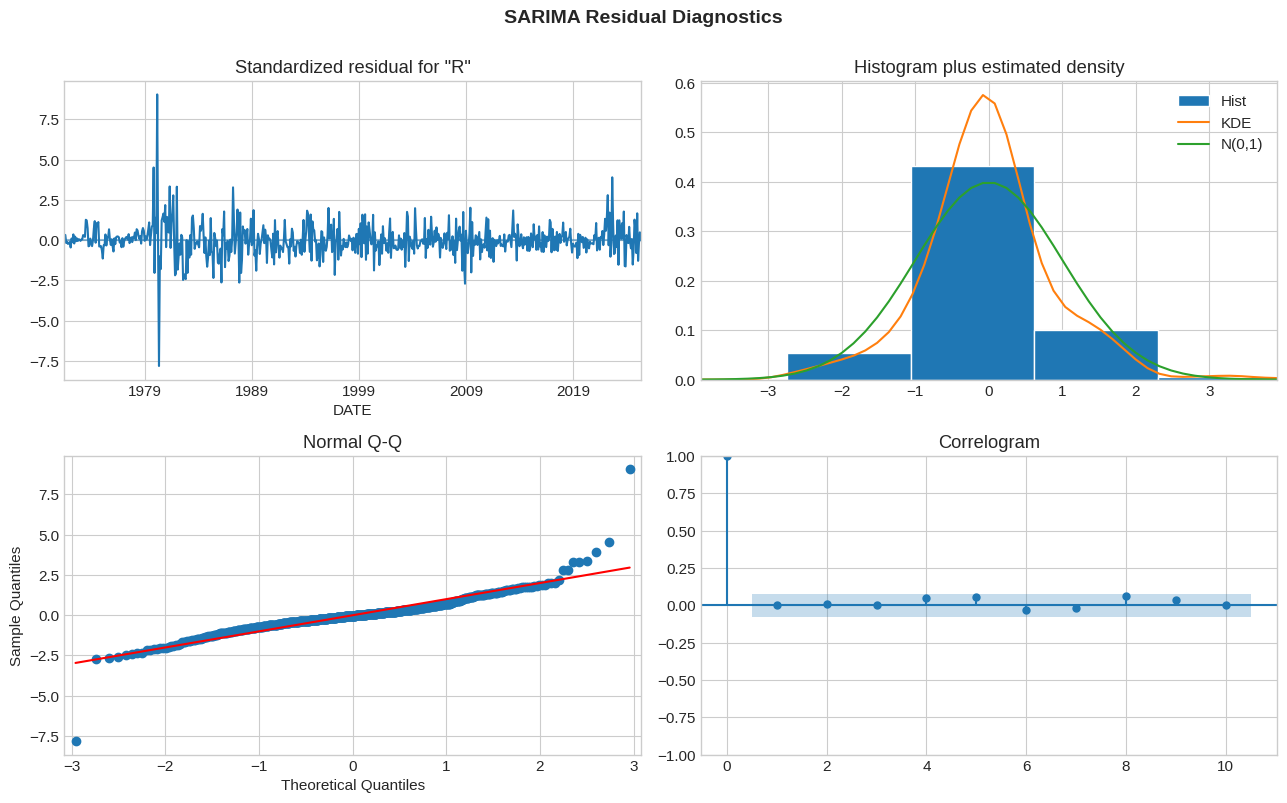

In [15]:
sarima = SARIMAX(train['Rate'], order=best_order, seasonal_order=best_sorder,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc_obj = sarima.get_forecast(12)
sarima_fc = sarima_fc_obj.predicted_mean
sarima_ci = sarima_fc_obj.conf_int()

sarima_mae, sarima_rmse, sarima_mape = metrics(test['Rate'], sarima_fc)
print(f'SARIMA test:  MAE={sarima_mae:.4f}  RMSE={sarima_rmse:.4f}  MAPE={sarima_mape:.2f}%')

fig = sarima.plot_diagnostics(figsize=(13, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## 7. Prophet Model

Facebook's Prophet decomposes a series into trend, yearly seasonality, and holidays. It is robust to missing data and handles changepoints automatically. I include it as a non-statistical comparison.

Prophet test:  MAE=0.7242  RMSE=0.7607  MAPE=11.30%


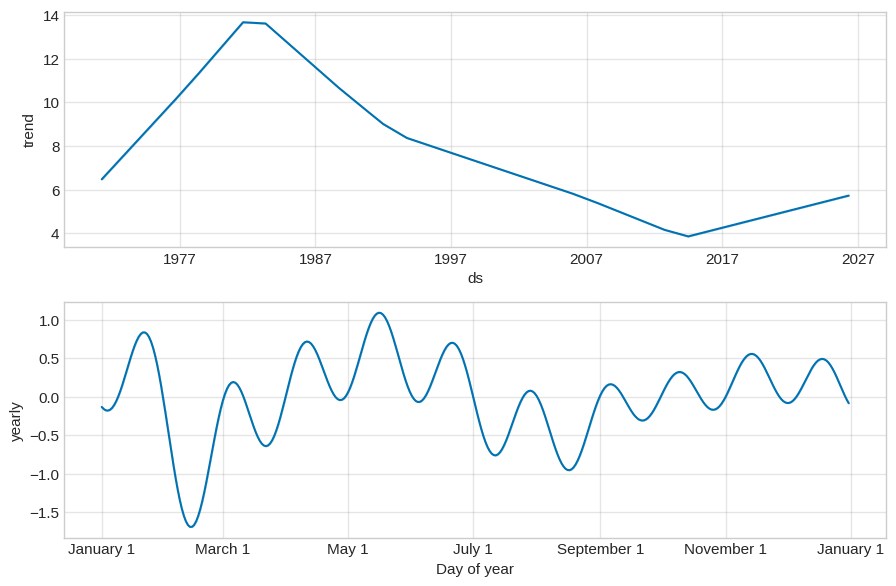

In [16]:
!pip install prophet -q

from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    daily_seasonality=False, changepoint_prior_scale=0.05)
prophet_m.fit(prophet_train)

future = prophet_m.make_future_dataframe(periods=12, freq='MS')
forecast_df = prophet_m.predict(future)
prophet_fc = pd.Series(forecast_df['yhat'].iloc[-12:].values, index=test.index)

prophet_mae, prophet_rmse, prophet_mape = metrics(test['Rate'].values, prophet_fc.values)
print(f'Prophet test:  MAE={prophet_mae:.4f}  RMSE={prophet_rmse:.4f}  MAPE={prophet_mape:.2f}%')

fig = prophet_m.plot_components(forecast_df)
plt.show()

## 8. Model Comparison

All four models are evaluated on the same 12-month hold-out window. I rank by RMSE because it penalizes large errors more heavily than MAE, important for a financial variable where tail moves matter. MAPE is included for an interpretable percentage view.

In [17]:
comparison = pd.DataFrame({
    'Model': ['Holt-Winters (baseline)', 'Holt-Winters (optimized)', 'SARIMA', 'Prophet'],
    'MAE':   [mae,       hw_opt_mae,  sarima_mae,  prophet_mae],
    'RMSE':  [rmse,      hw_opt_rmse, sarima_rmse, prophet_rmse],
    'MAPE':  [mape,      hw_opt_mape, sarima_mape, prophet_mape],
}).round(4).sort_values('RMSE').reset_index(drop=True)
comparison

,Model,MAE,RMSE,MAPE
0,Holt-Winters (optimized),0.4082,0.4500,6.5405
1,SARIMA,0.4594,0.5127,7.3724
2,Holt-Winters (baseline),0.4672,0.5212,7.4975
3,Prophet,0.7242,0.7607,11.2976


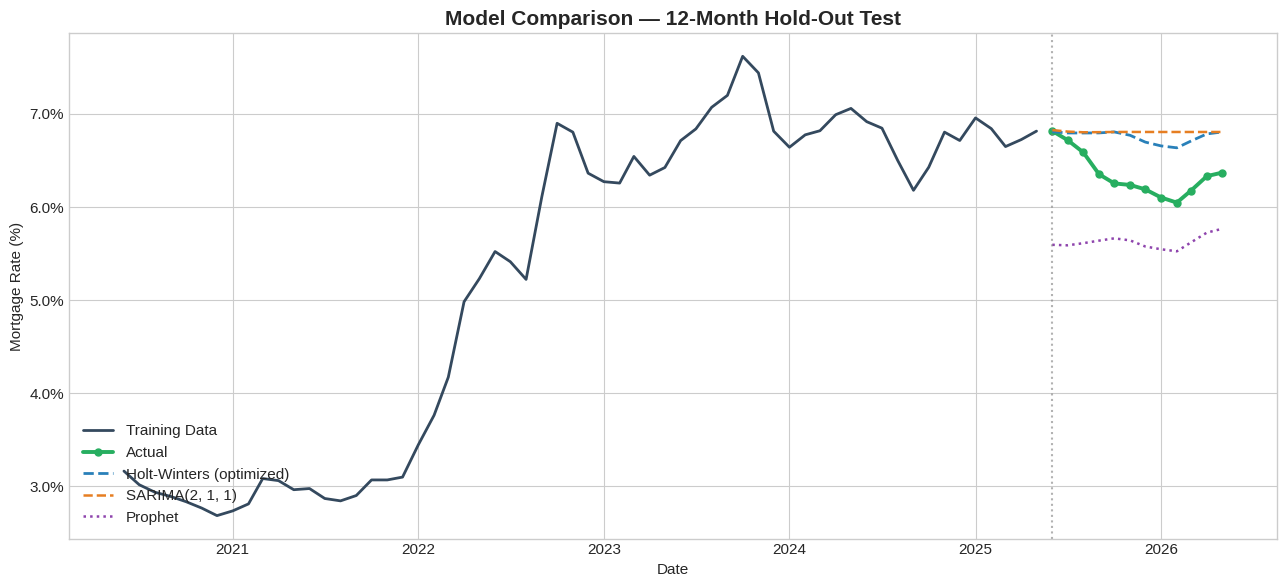

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-60:], train['Rate'].iloc[-60:], color='#34495e',
        linewidth=2, label='Training Data')
ax.plot(test.index, test['Rate'], color='#27ae60', linewidth=2.8,
        label='Actual', marker='o', markersize=5)
ax.plot(test.index, hw_opt_fc, color='#2980b9', linewidth=2,
        linestyle='--', label='Holt-Winters (optimized)')
ax.plot(test.index, sarima_fc, color='#e67e22', linewidth=1.8,
        linestyle='--', label=f'SARIMA{best_order}')
ax.plot(test.index, prophet_fc, color='#8e44ad', linewidth=1.8,
        linestyle=':', label='Prophet')
ax.axvline(test.index[0], color='gray', linestyle=':', alpha=0.6)

ax.set_title('Model Comparison — 12-Month Hold-Out Test', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mortgage Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax.legend(loc='lower left', framealpha=0.95)
plt.tight_layout()
plt.show()

## 9. Final 12-Month Forecast

I select the best model from Section 8 (Holt-Winters, optimized) and refit on the full series, no hold-out, since validation is complete. The forecast extends 12 months past the most recent observation, with a 95% confidence band derived from in-sample residual standard deviation.

In [19]:
hw_full = ExponentialSmoothing(df_monthly['Rate'], trend=best_trend,
                                seasonal=best_seasonal, seasonal_periods=12,
                                damped_trend=best_damped).fit(optimized=True)
fc_future = hw_full.forecast(12)

resid_std = hw_full.resid.std()
horizon = np.arange(1, 13)
lower = fc_future - 1.96 * resid_std * np.sqrt(horizon)
upper = fc_future + 1.96 * resid_std * np.sqrt(horizon)

fc_table = pd.DataFrame({
    'Forecast': fc_future.round(2),
    'Lower 95%': lower.round(2),
    'Upper 95%': upper.round(2),
})
fc_table.index = fc_table.index.strftime('%b %Y')
fc_table

,Forecast,Lower 95%,Upper 95%
Jun 2026,6.36,5.84,6.89
Jul 2026,6.35,5.60,7.10
Aug 2026,6.35,5.43,7.26
Sep 2026,6.34,5.29,7.40
Oct 2026,6.35,5.17,7.53
Nov 2026,6.32,5.02,7.61
Dec 2026,6.24,4.85,7.64
Jan 2027,6.20,4.71,7.69
Feb 2027,6.18,4.60,7.76
Mar 2027,6.25,4.59,7.92


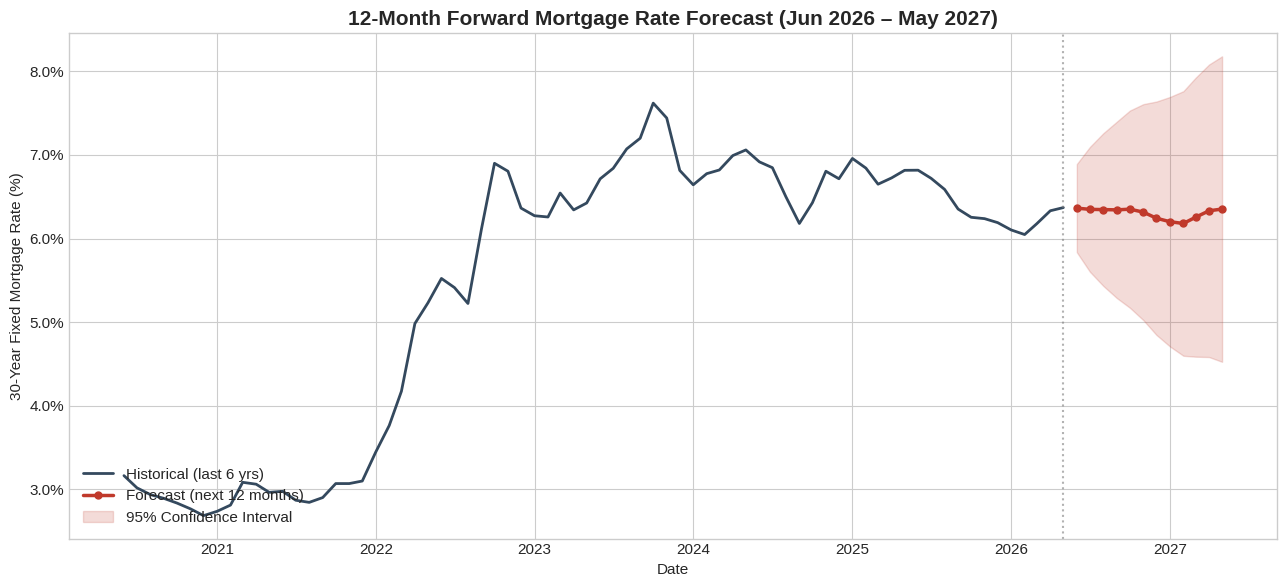


Forecast summary:
  Latest actual: 6.37% (May 2026)
  Forecast trough: 6.18% in Feb 2027
  Forecast peak:   6.36% in Jun 2026
  12-month-out:    6.35% in May 2027


In [20]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_monthly.index[-72:], df_monthly['Rate'].iloc[-72:],
        color='#34495e', linewidth=2, label='Historical (last 6 yrs)')
ax.plot(fc_future.index, fc_future, color='#c0392b', linewidth=2.5,
        label='Forecast (next 12 months)', marker='o', markersize=5)
ax.fill_between(fc_future.index, lower, upper, color='#c0392b',
                alpha=0.18, label='95% Confidence Interval')
ax.axvline(df_monthly.index[-1], color='gray', linestyle=':', alpha=0.6)

ax.set_title(f'12-Month Forward Mortgage Rate Forecast '
             f'({fc_future.index[0].strftime("%b %Y")} \u2013 {fc_future.index[-1].strftime("%b %Y")})',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('30-Year Fixed Mortgage Rate (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax.legend(loc='lower left', framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"\nForecast summary:")
print(f"  Latest actual: {df_monthly['Rate'].iloc[-1]:.2f}% ({df_monthly.index[-1].strftime('%b %Y')})")
print(f"  Forecast trough: {fc_future.min():.2f}% in {fc_future.idxmin().strftime('%b %Y')}")
print(f"  Forecast peak:   {fc_future.max():.2f}% in {fc_future.idxmax().strftime('%b %Y')}")
print(f"  12-month-out:    {fc_future.iloc[-1]:.2f}% in {fc_future.index[-1].strftime('%b %Y')}")